# KRONOS Object Detection & Fact Extraction

This notebook runs YOLO object detection on CXR images and extracts structured `PerceptualFact` objects.

In [6]:
import sys
import os

# Add project root to path
sys.path.append(os.path.abspath('../../'))

In [7]:
from src.perception.backbone import load_model, predict_image
from src.perception.grounding import plot_image_with_bounding_box, extract_facts

In [8]:
# Load model and run prediction
model = load_model()
img_path = '../../data/vindr_cxr_vqa/train/000434271f63a053c4128a0ba6352c7f.png'

results = predict_image(model, img_path, conf=0.1, iou=0.45)


image 1/1 h:\CN12_AI\MORAI_lab\KRONOS\src\perception\..\..\data\vindr_cxr_vqa\train\000434271f63a053c4128a0ba6352c7f.png: 512x512 1 Nodule/Mass, 180.4ms
Speed: 4.6ms preprocess, 180.4ms inference, 47.6ms postprocess per image at shape (1, 3, 512, 512)


In [9]:
# Extract and print facts
facts = extract_facts(results)
print(f"Extracted {len(facts)} facts:")
for f in facts:
    print(f)

Extracted 1 facts:
concept='Cardiomegaly' bbox=(198.64288330078125, 271.06866455078125, 435.5615234375, 380.76690673828125) laterality='midline' conf=0.16503889858722687


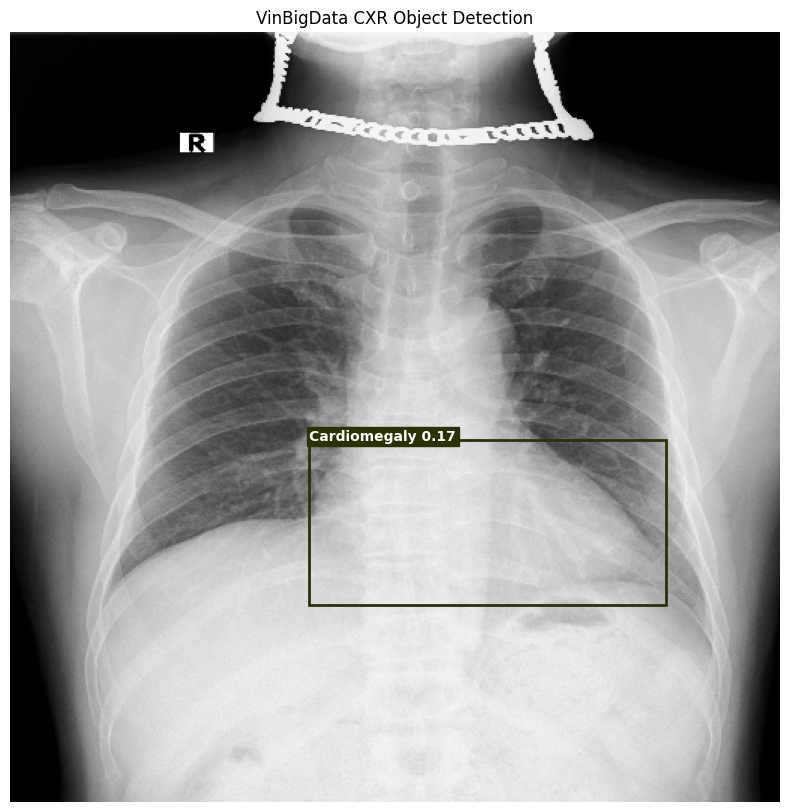

In [10]:
# Visualize
plot_image_with_bounding_box(img_path, results)